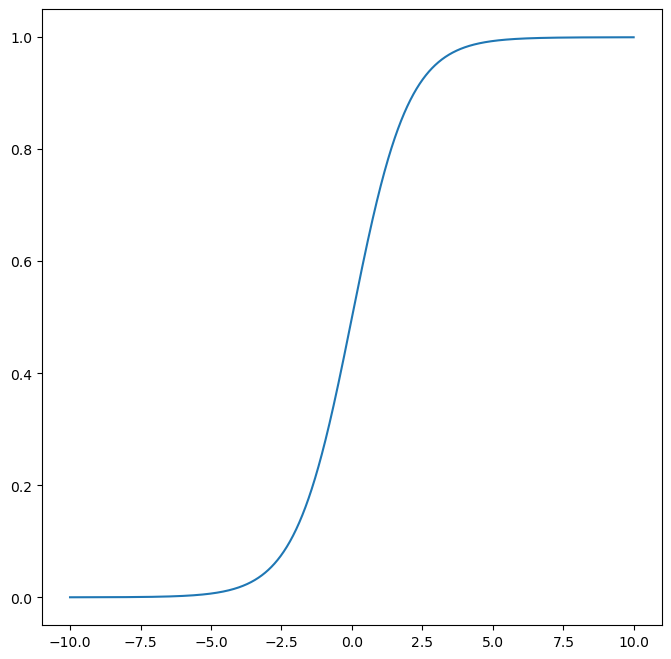

In [2]:
# Logistic Function
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

z = np.arange(-10, 10, 0.01)
g = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 8))

plt.plot(z, g)

plt.show()

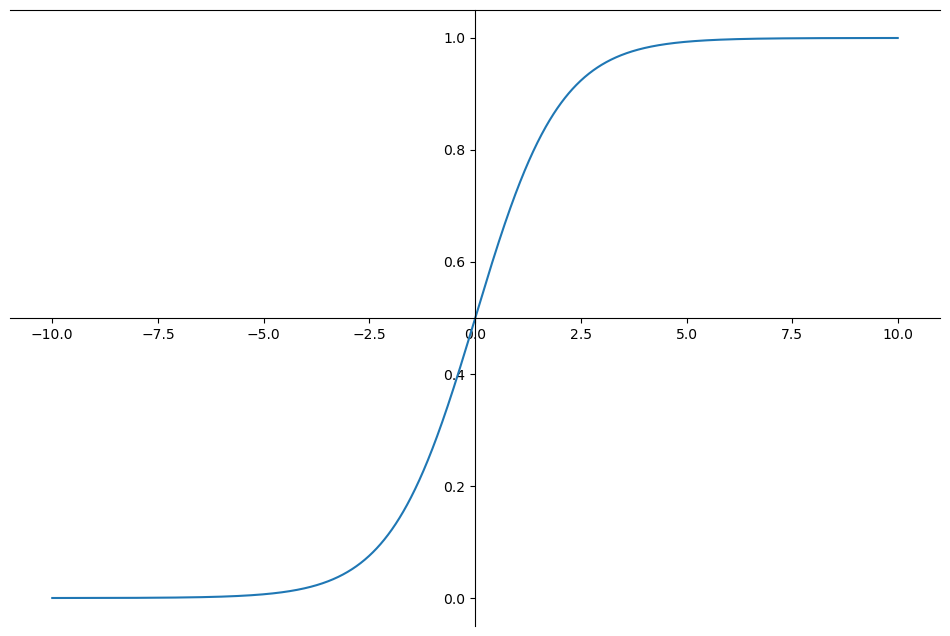

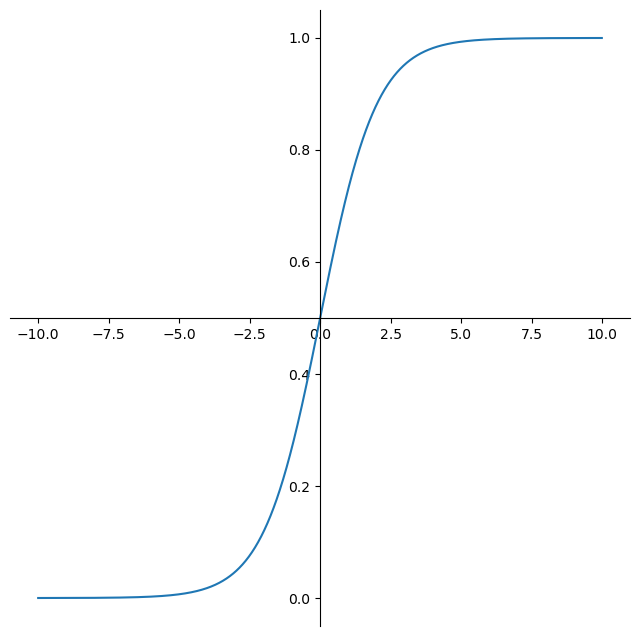

In [4]:
plt.figure(figsize=(8, 8))

ax = plt.gca()

ax.plot(z, g)

ax.spines['left'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('center')
ax.spines['top'].set_color('none')

plt.show()

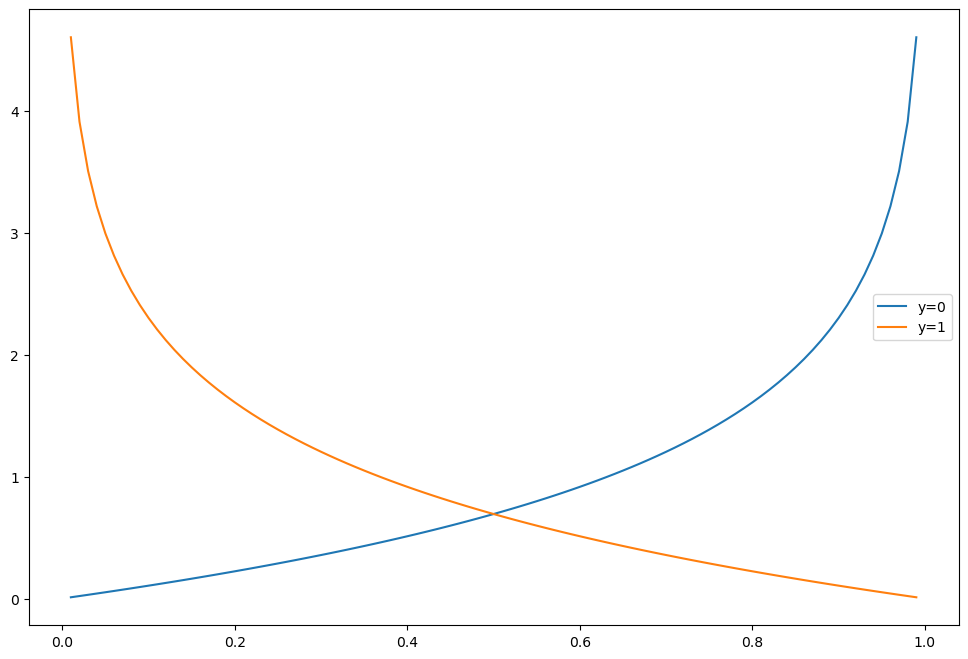

In [5]:
h = np.arange(0.01, 1, 0.01)

c0 = -np.log(1 - h)
c1 = -np.log(h)

plt.figure(figsize=(12, 8))

plt.plot(h, c0, label='y=0')
plt.plot(h, c1, label='y=1')

plt.legend()
plt.show()

In [7]:
import pandas as pd

wine_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/wine.csv'
    
wine = pd.read_csv(wine_url, index_col = 0)
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [8]:
# taste feature 생성
wine['taste'] = [1 if grade > 5 else 0 for grade in wine['quality']]

wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color,taste
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,0


In [9]:
# Data Split
from sklearn.model_selection import train_test_split

x = wine.drop(['taste', 'quality'], axis=1)
y = wine['taste']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)

In [11]:
# LogisticRegression Model 생성
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(solver='liblinear', random_state=13)
lr.fit(x_train, y_train)

pred_train = lr.predict(x_train)
pred_test = lr.predict(x_test)

print(f'Train Acc: {accuracy_score(y_train, pred_train)}')
print(f'Test Acc: {accuracy_score(y_test, pred_test)}')

Train Acc: 0.7429286126611506
Test Acc: 0.7446153846153846


In [13]:
# Pipeline 생성 및 학습
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

estimators = [
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=13))
]
pipe = Pipeline(estimators)

pipe.fit(x_train, y_train)

pred_train = pipe.predict(x_train)
pred_test = pipe.predict(x_test)

print(f'Train Acc: {accuracy_score(y_train, pred_train)}')
print(f'Test Acc: {accuracy_score(y_test, pred_test)}')

Train Acc: 0.7444679622859341
Test Acc: 0.7469230769230769


In [14]:
# Decision Tree Classifier 생성
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(max_depth=2, random_state=13)
dtc.fit(x_train, y_train)

models = {
    'logistic regression': lr,
    'decision tree': dtc
}

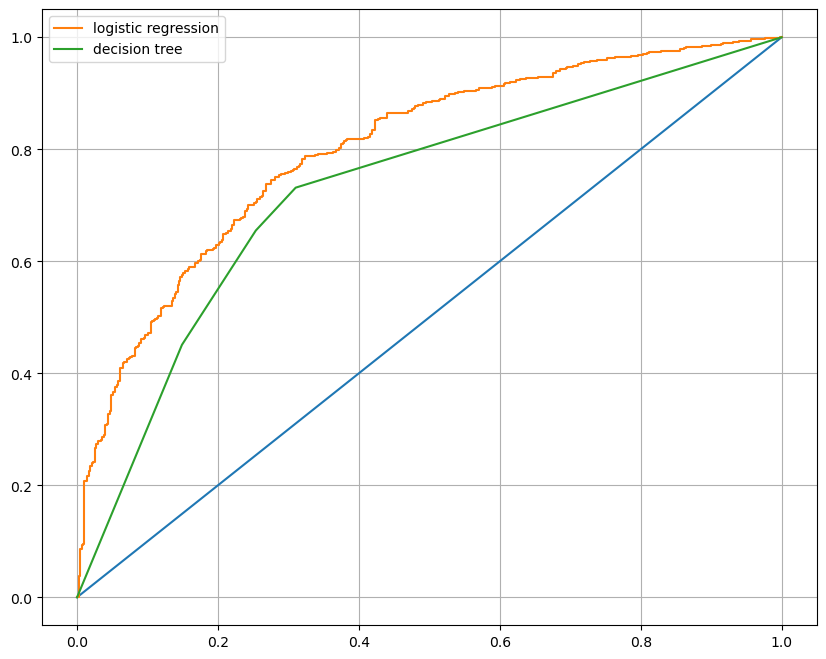

In [ ]:
# Logistic Regression, Decision Tree Classifier ROC Curve 비교
# ROC Curve 기준 Logistic 모델의 성능이 더 좋은 것으로 나타남
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

plt.plot([0, 1], [0, 1])
for model_name, model in models.items():
    pred = model.predict_proba(x_test)[:, 1]
    fpr, tpr, threhold = roc_curve(y_test, pred)
    plt.plot(fpr, tpr, label=model_name)

plt.grid()
plt.legend()
plt.show()

In [16]:
# PIMA 인디언 당뇨병 데이터
# Raw Data Loading
PIMA_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/diabetes.csv'

PIMA = pd.read_csv(PIMA_url)
PIMA.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
PIMA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [18]:
# 학습을 위해 float 자료형으로 변환
PIMA = PIMA.astype(float)
PIMA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB


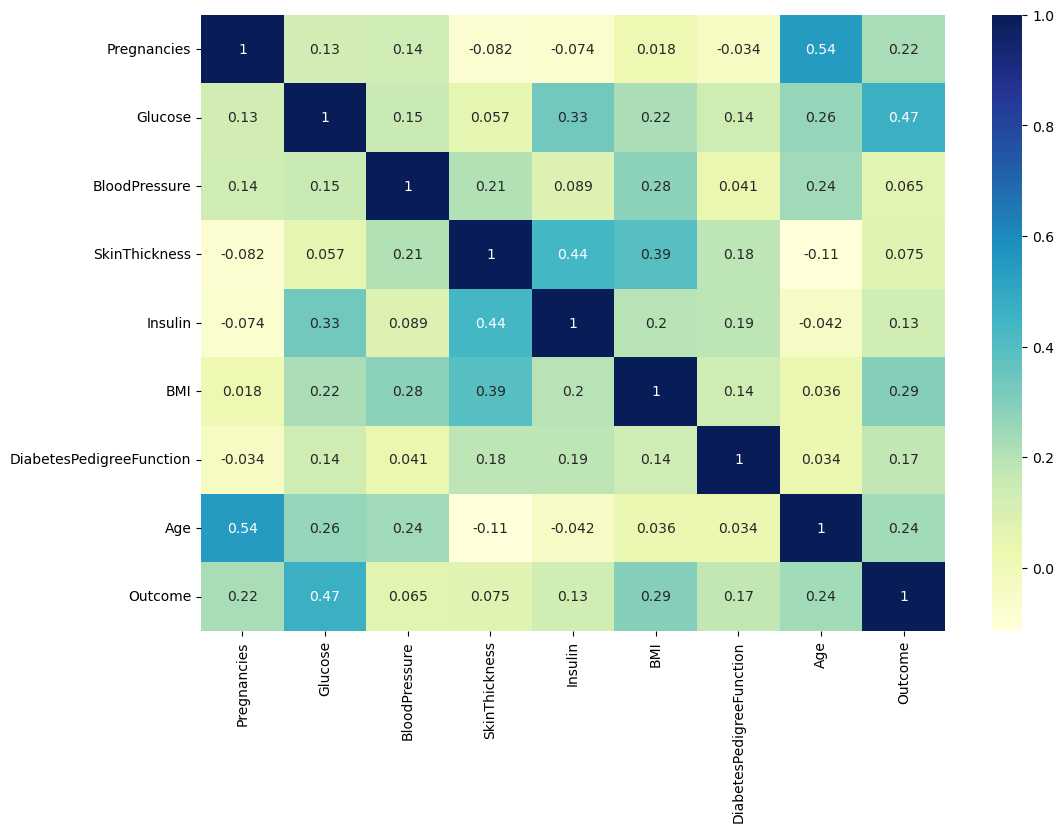

In [20]:
# 상관관계 시각화
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(PIMA.corr(),
            annot=True,
            cmap='YlGnBu')

plt.show()

In [ ]:
# 결측치 존재
# 이때도 판단 필요
# ex. BloodPressure(혈압)이 0일 수는 없음
(PIMA == 0).astype(int).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [22]:
# 평균값으로 대체
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']

PIMA[zero_features] = PIMA[zero_features].replace(0, PIMA[zero_features].mean())
(PIMA == 0).astype(int).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                     374
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [23]:
# Data Split
x = PIMA.drop(['Outcome'], axis=1)
y = PIMA['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=13)

In [ ]:
# Model 학습
estimators = [
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=13))
]

pipe_lr = Pipeline(estimators)
pipe_lr.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(random_state=13, solver='liblinear'))])

In [25]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score

pred = pipe_lr.predict(x_test)

print('Accuracy : ', accuracy_score(y_test, pred))
print('Recall : ', recall_score(y_test, pred))
print('Precision : ', precision_score(y_test, pred))
print('AUC score : ', roc_auc_score(y_test, pred))
print('F1 Score : ', f1_score(y_test, pred))

Accuracy :  0.7727272727272727
Recall :  0.6111111111111112
Precision :  0.7021276595744681
AUC score :  0.7355555555555556
F1 Score :  0.6534653465346535


In [27]:
coef = list(pipe_lr['clf'].coef_[0])
labels = list(x_train.columns)

print(coef)
print(labels)

[0.35426588844126494, 1.2014244425037581, -0.15840135536286717, 0.03394657712929955, -0.16286471953988127, 0.620404521989511, 0.36669355795578734, 0.17195965447035091]
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


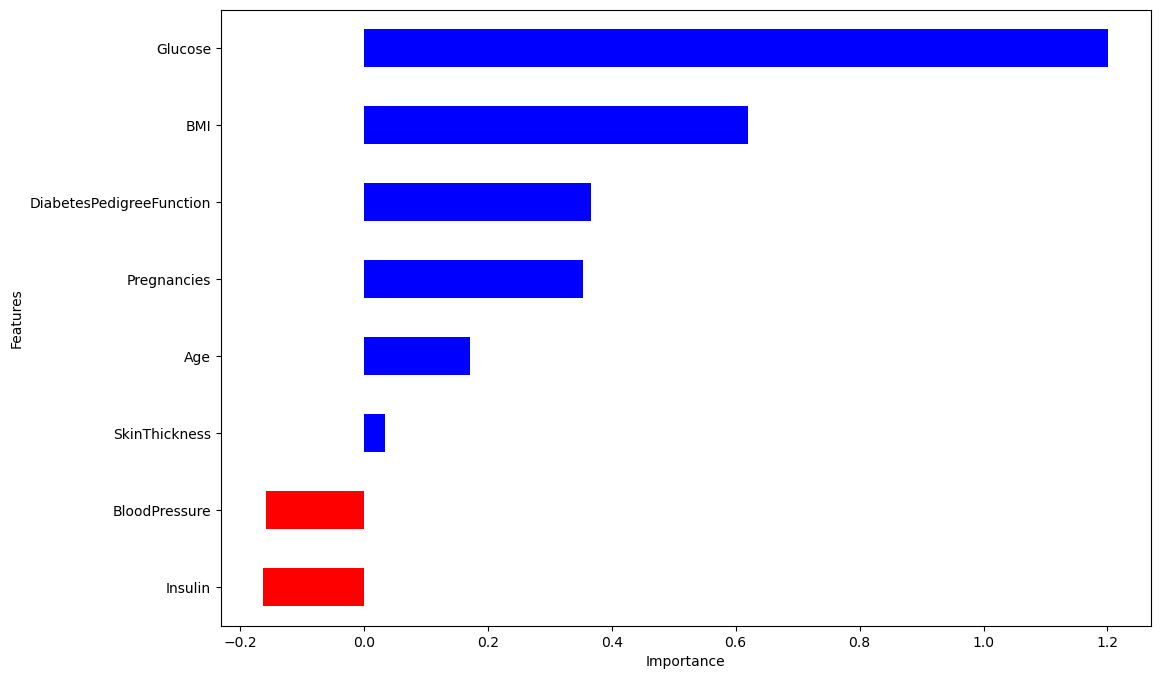

In [ ]:
# 주요 feature 시각화
features = pd.DataFrame(
    {'Features': labels,
     'importance': coef}
)
features.sort_values(by=['importance'], ascending=True, inplace=True)

features['positive'] = features['importance'] > 0
features.set_index('Features', inplace=True)

features['importance'].plot(kind='barh',
                            figsize=(12, 8),
                            color=features['positive'].map({True: 'blue',
                                                            False: 'red'}))

plt.xlabel('Importance')
plt.show()